In [1]:
print("OK")

OK


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

MASTER = Path(
    "/kaggle/input/notebooks/shri7ul/master-dataset-creation/master/master_train.parquet"
)

master = pd.read_parquet(MASTER)

print(master.shape)
master.head()

(35072, 9)


,response_id,session_id,learning_objective_id,learning_objective,transcript,student_text,tutor_text,background_text,is_correct
0,aaaavsh,bcaufvc,dqibnvd,Knowing the value of each digit in numbers wit...,"[BACKGROUND] [unclear]\n[TUTOR] Miss, I can't ...","Can you hear me? Hello? Yeah, I hear you. Can ...","Miss, I can't hear. Can you hear me? [unclear]...","[unclear] Good, very good. [unclear] And we wi...",1.0
1,aaabhzi,eyutanf,eukmzxl,Adding and subtracting tens to a 2-digit number.,[TUTOR] Yay! Hello!\n[STUDENT] Hello.\n[TUTOR]...,Hello. Hello. I was one minute early. I'm one ...,Yay! Hello! Hello. Hello. [Speaker:Background]...,20. What 2-digit number can you make using the...,1.0
2,aaahpnz,juptkxd,fjbqcsv,Comparing and ordering fractions by finding a ...,[BACKGROUND] [unclear]\n[TUTOR] Is it me you a...,Hello. Hello. Yes. Good. How are you? Normal. ...,"Is it me you are looking for? Okay, so did you...","[unclear] Hello. Hello, Callum. Can you hear m...",0.0
3,aaajpom,ntwkcfj,acvbcev,Comparing fractions using reasoning.,[BACKGROUND] [unclear]\n[TUTOR] Hello?\n[STUDE...,"Hello, Tobias. Can you hear me? Okay, that's n...","Hello? Yes, I can hear you. Good. Why are you ...","[unclear] 1.45 meters. Excellent. Yes, good. G...",0.0
4,aaamwux,jqriibm,krfuudx,Counting in multiples.,[BACKGROUND] [unclear]\n[TUTOR] Hello.\n[STUDE...,"Hello. Good. Okay, how was this week for you? ...",Hello. Hello. Are you feeling tired today? Is ...,"[unclear] Hello. Hi, Caelum. How are you doing...",0.0


In [3]:
# ==========================================================
# Learning Objective Frequency Features
# ==========================================================

objective_freq = (
    master["learning_objective"]
    .value_counts()
)

master["objective_frequency"] = (
    master["learning_objective"]
    .map(objective_freq)
)

master["log_objective_frequency"] = np.log1p(
    master["objective_frequency"]
)

master["is_rare_objective"] = (
    master["objective_frequency"] <= 10
).astype("int8")

display(
    master[
        [
            "learning_objective",
            "objective_frequency",
            "log_objective_frequency",
            "is_rare_objective",
        ]
    ].head()
)

,learning_objective,objective_frequency,log_objective_frequency,is_rare_objective
0,Knowing the value of each digit in numbers wit...,1267,7.145196,0
1,Adding and subtracting tens to a 2-digit number.,44,3.806662,0
2,Comparing and ordering fractions by finding a ...,211,5.356586,0
3,Comparing fractions using reasoning.,510,6.236370,0
4,Counting in multiples.,525,6.265301,0


In [4]:
# ==========================================================
# Objective Frequency Percentile
# ==========================================================

master["objective_frequency_percentile"] = (
    master["objective_frequency"]
    .rank(pct=True)
)

display(
    master[
        [
            "objective_frequency",
            "objective_frequency_percentile",
        ]
    ].describe()
)

,objective_frequency,objective_frequency_percentile
count,35072.000000,35072.000000
mean,432.518818,0.500014
std,331.514553,0.288635
min,1.000000,0.000955
25%,205.000000,0.247548
50%,393.000000,0.496835
75%,530.000000,0.737155
max,1373.000000,0.980440


In [5]:
# ==========================================================
# Objective Length Features
# ==========================================================

master["objective_char_count"] = (
    master["learning_objective"]
    .str.len()
)

master["objective_word_count"] = (
    master["learning_objective"]
    .str.split()
    .str.len()
)

master["objective_avg_word_length"] = (
    master["objective_char_count"]
    /
    master["objective_word_count"]
)

display(
    master[
        [
            "objective_char_count",
            "objective_word_count",
            "objective_avg_word_length",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
objective_char_count,35072.0,42.366760,13.621690,15.0,33.0,40.0,52.000000,83.0
objective_word_count,35072.0,6.334426,2.715170,2.0,5.0,6.0,7.000000,14.0
objective_avg_word_length,35072.0,7.051141,1.310336,4.5,6.0,7.0,7.714286,14.0


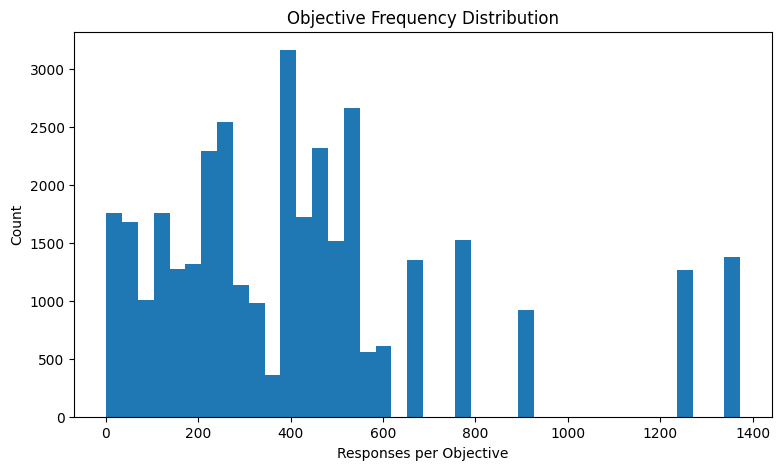

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.hist(
    master["objective_frequency"],
    bins=40
)

plt.title("Objective Frequency Distribution")
plt.xlabel("Responses per Objective")
plt.ylabel("Count")

plt.show()

In [7]:
print("=" * 60)

print("Rare Objectives")

print("=" * 60)

print(
    "Rare Responses :",
    master["is_rare_objective"].sum()
)

print(
    "Percentage :",
    round(
        master["is_rare_objective"].mean()*100,
        2
    ),
    "%"
)

display(
    master.loc[
        master["is_rare_objective"]==1,
        [
            "learning_objective",
            "objective_frequency"
        ]
    ]
    .drop_duplicates()
    .sort_values("objective_frequency")
    .head(20)
)

Rare Objectives
Rare Responses : 630
Percentage : 1.8 %


,learning_objective,objective_frequency
217,"Finding the area, circumference and lengths of...",1
420,Combining and Subdividing Ratios,1
590,Calculating with Fractions in Context,1
1258,Solving simple simultaneous equations by elimi...,1
1579,Describing positions on a coordinate grid,1
2942,Using multiplication facts and place value to ...,1
3035,Working out the 10 times tables using a number...,1
1975,Dividing mentally using factors,1
4084,Comparing regular and irregular polygons,1
3750,Calculating the area of a trapezium,1


In [8]:
# ==========================================================
# Objective Keyword Features
# ==========================================================

keywords = [
    "fraction",
    "decimal",
    "money",
    "graph",
    "table",
    "probability",
    "ratio",
    "angle",
    "shape",
    "division",
    "multiply",
    "multiplication",
    "addition",
    "subtract",
    "subtraction",
    "equation",
    "percentage",
    "volume",
    "area",
    "length",
]

objective_lower = (
    master["learning_objective"]
    .str.lower()
)

for word in keywords:
    col = f"obj_has_{word.replace(' ', '_')}"
    master[col] = (
        objective_lower
        .str.contains(word, regex=False)
        .astype("int8")
    )

print(f"Created {len(keywords)} keyword features.")

display(
    master[
        [c for c in master.columns if c.startswith("obj_has_")]
    ].sum()
    .sort_values(ascending=False)
)

Created 20 keyword features.


obj_has_decimal           7813
obj_has_fraction          6827
obj_has_multiply          4770
obj_has_subtract          3713
obj_has_multiplication    2288
obj_has_money             1417
obj_has_division          1374
obj_has_percentage        1003
obj_has_addition           971
obj_has_subtraction        971
obj_has_area               631
obj_has_table              408
obj_has_angle              360
obj_has_ratio              275
obj_has_shape              137
obj_has_equation            84
obj_has_graph               39
obj_has_volume              25
obj_has_probability         16
obj_has_length              13
dtype: int64

obj_has_decimal           7813
obj_has_fraction          6827
obj_has_multiply          4770
obj_has_subtract          3713
obj_has_multiplication    2288
obj_has_money             1417
obj_has_division          1374
obj_has_percentage        1003
obj_has_addition           971
obj_has_subtraction        971
obj_has_area               631
obj_has_table              408
obj_has_angle              360
obj_has_ratio              275
obj_has_shape              137
obj_has_equation            84
obj_has_graph               39
obj_has_volume              25
obj_has_probability         16
obj_has_length              13
dtype: int64

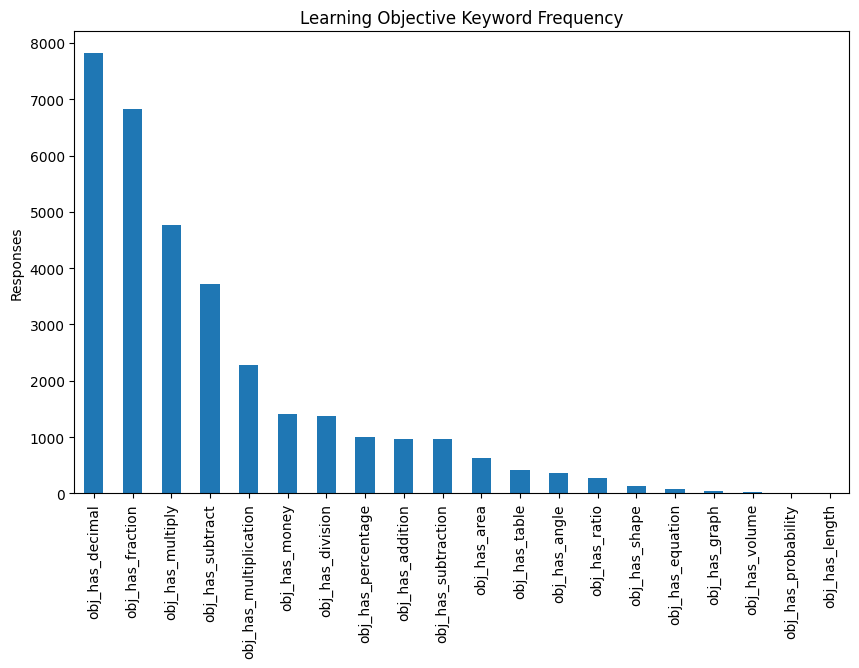

In [9]:
keyword_cols = [
    c for c in master.columns
    if c.startswith("obj_has_")
]

keyword_summary = (
    master[keyword_cols]
    .sum()
    .sort_values(ascending=False)
)

display(keyword_summary)

plt.figure(figsize=(10,6))

keyword_summary.plot(kind="bar")

plt.title("Learning Objective Keyword Frequency")
plt.ylabel("Responses")

plt.show()

In [10]:
# ==========================================================
# Objective Family
# ==========================================================

def objective_family(text):

    text = str(text).lower()

    if any(k in text for k in [
        "fraction",
        "decimal",
        "percentage",
        "ratio"
    ]):
        return "Fractions_Decimals"

    elif any(k in text for k in [
        "money",
        "price",
        "cost",
        "change"
    ]):
        return "Money"

    elif any(k in text for k in [
        "graph",
        "table",
        "probability",
        "statistics"
    ]):
        return "Data"

    elif any(k in text for k in [
        "shape",
        "angle",
        "area",
        "volume",
        "length",
        "perimeter"
    ]):
        return "Geometry"

    elif any(k in text for k in [
        "multiply",
        "multiplication",
        "divide",
        "division",
        "addition",
        "subtract",
        "equation",
        "algebra"
    ]):
        return "Arithmetic"

    else:
        return "Other"


master["objective_family"] = (
    master["learning_objective"]
    .apply(objective_family)
)

display(
    master["objective_family"]
    .value_counts()
)

objective_family
Fractions_Decimals    14082
Other                 11358
Arithmetic             6944
Geometry               1268
Money                   962
Data                    458
Name: count, dtype: int64

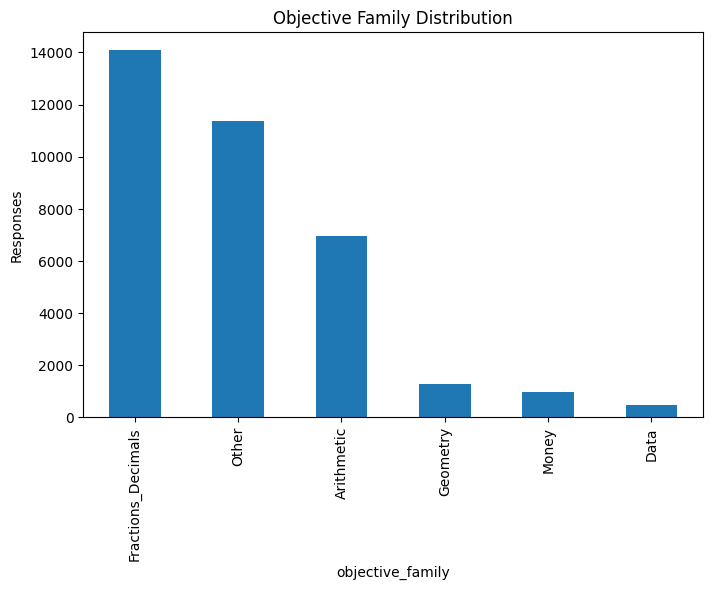

In [11]:
plt.figure(figsize=(8,5))

master["objective_family"] \
    .value_counts() \
    .plot(kind="bar")

plt.title("Objective Family Distribution")
plt.ylabel("Responses")

plt.show()

,count,mean
objective_family,,
Money,962,0.557173
Geometry,1268,0.665615
Arithmetic,6944,0.688364
Other,11358,0.701620
Data,458,0.720524
Fractions_Decimals,14082,0.722767


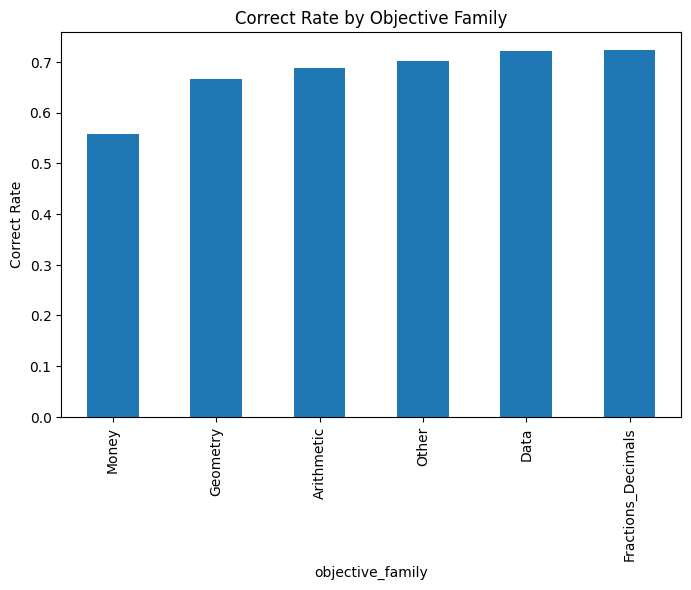

In [12]:
family_target = (
    master
    .groupby("objective_family")["is_correct"]
    .agg(["count", "mean"])
    .sort_values("mean")
)

display(family_target)

plt.figure(figsize=(8,5))

family_target["mean"].plot(kind="bar")

plt.title("Correct Rate by Objective Family")
plt.ylabel("Correct Rate")

plt.show()

In [13]:
# ==========================================================
# Text Length Features
# ==========================================================

master["transcript_chars"] = master["transcript"].str.len()

master["student_chars"] = master["student_text"].str.len()

master["tutor_chars"] = master["tutor_text"].str.len()

master["background_chars"] = master["background_text"].str.len()


master["transcript_words"] = master["transcript"].str.split().str.len()

master["student_words"] = master["student_text"].str.split().str.len()

master["tutor_words"] = master["tutor_text"].str.split().str.len()

master["background_words"] = master["background_text"].str.split().str.len()

display(
    master[
        [
            "transcript_chars",
            "student_chars",
            "tutor_chars",
            "background_chars",
            "transcript_words",
            "student_words",
            "tutor_words",
            "background_words",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
transcript_chars,35072.0,20961.532505,5110.980174,561.0,17732.75,21126.0,24308.0,49333.0
student_chars,35072.0,4998.790431,2052.623931,0.0,3559.00,4827.0,6232.0,16207.0
tutor_chars,35072.0,12942.306199,3723.534484,53.0,10447.00,12840.0,15265.0,33781.0
background_chars,35072.0,582.049698,592.612255,0.0,189.00,423.0,780.0,9976.0
transcript_words,35072.0,3857.894332,974.693232,63.0,3242.75,3892.0,4501.0,8983.0
student_words,35072.0,982.139570,423.373298,0.0,682.00,942.0,1233.0,3350.0
tutor_words,35072.0,2496.893761,732.168726,6.0,2006.00,2475.0,2956.0,6372.0
background_words,35072.0,110.518277,114.737460,0.0,35.00,80.0,149.0,1976.0


In [14]:
# ==========================================================
# Log Features
# ==========================================================

length_cols = [
    "transcript_chars",
    "student_chars",
    "tutor_chars",
    "background_chars",
]

for c in length_cols:
    master[f"log_{c}"] = np.log1p(master[c])

display(
    master[
        [f"log_{c}" for c in length_cols]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
log_transcript_chars,35072.0,9.913824,0.296443,6.331502,9.783225,9.958307,10.098602,10.806369
log_student_chars,35072.0,8.415800,0.512289,0.000000,8.177516,8.482188,8.737613,9.693260
log_tutor_chars,35072.0,9.419050,0.343818,3.988984,9.254166,9.460398,9.633383,10.427683
log_background_chars,35072.0,5.811661,1.289287,0.000000,5.247024,6.049733,6.660575,9.208038


In [15]:
# ==========================================================
# Ratio Features
# ==========================================================

master["student_fraction"] = (
    master["student_chars"] /
    (master["transcript_chars"] + 1)
)

master["tutor_fraction"] = (
    master["tutor_chars"] /
    (master["transcript_chars"] + 1)
)

master["background_fraction"] = (
    master["background_chars"] /
    (master["transcript_chars"] + 1)
)

master["tutor_student_ratio"] = (
    (master["tutor_chars"] + 1) /
    (master["student_chars"] + 1)
)

master["log_tutor_student_ratio"] = np.log1p(
    master["tutor_student_ratio"]
)

display(
    master[
        [
            "student_fraction",
            "tutor_fraction",
            "background_fraction",
            "tutor_student_ratio",
            "log_tutor_student_ratio",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
student_fraction,35072.0,0.238395,0.079221,0.000000,0.183327,0.233948,0.288481,0.728135
tutor_fraction,35072.0,0.616289,0.088361,0.075606,0.558340,0.616069,0.675318,0.952948
background_fraction,35072.0,0.027263,0.025834,0.000000,0.009785,0.020872,0.036812,0.341171
tutor_student_ratio,35072.0,6.459986,194.024989,0.137056,1.952232,2.635455,3.657648,14491.000000
log_tutor_student_ratio,35072.0,1.340172,0.406175,0.128442,1.082561,1.290734,1.538511,9.581352


In [16]:
# ==========================================================
# Difference Features
# ==========================================================

master["student_minus_tutor"] = (
    master["student_chars"] -
    master["tutor_chars"]
)

master["tutor_minus_student"] = (
    master["tutor_chars"] -
    master["student_chars"]
)

display(
    master[
        [
            "student_minus_tutor",
            "tutor_minus_student",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
student_minus_tutor,35072.0,-7943.515768,3972.283375,-27078.0,-10451.0,-7743.0,-5186.0,10193.0
tutor_minus_student,35072.0,7943.515768,3972.283375,-10193.0,5186.0,7743.0,10451.0,27078.0


In [17]:
# ==========================================================
# Conversation Structure Features
# ==========================================================

master["student_turns"] = master["transcript"].str.count(r"\[STUDENT\]")

master["tutor_turns"] = master["transcript"].str.count(r"\[TUTOR\]")

master["background_turns"] = master["transcript"].str.count(r"\[BACKGROUND\]")

master["total_turns"] = (
    master["student_turns"]
    + master["tutor_turns"]
    + master["background_turns"]
)

display(
    master[
        [
            "student_turns",
            "tutor_turns",
            "background_turns",
            "total_turns",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
student_turns,35072.0,117.876540,37.446791,0.0,94.0,117.0,142.0,295.0
tutor_turns,35072.0,139.686388,35.385532,4.0,117.0,139.0,162.0,559.0
background_turns,35072.0,10.779796,9.391006,0.0,5.0,8.0,14.0,110.0
total_turns,35072.0,268.342724,72.048838,15.0,222.0,266.0,313.0,622.0


In [18]:
# ==========================================================
# Turn Ratio Features
# ==========================================================

master["student_turn_fraction"] = (
    master["student_turns"]
    / (master["total_turns"] + 1)
)

master["tutor_turn_fraction"] = (
    master["tutor_turns"]
    / (master["total_turns"] + 1)
)

master["background_turn_fraction"] = (
    master["background_turns"]
    / (master["total_turns"] + 1)
)

master["turn_ratio"] = (
    (master["tutor_turns"] + 1)
    /
    (master["student_turns"] + 1)
)

master["log_turn_ratio"] = np.log1p(master["turn_ratio"])

display(
    master[
        [
            "student_turn_fraction",
            "tutor_turn_fraction",
            "background_turn_fraction",
            "turn_ratio",
            "log_turn_ratio",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
student_turn_fraction,35072.0,0.433461,0.059074,0.000000,0.407895,0.443709,0.471429,0.800000
tutor_turn_fraction,35072.0,0.523012,0.048464,0.153846,0.493865,0.516556,0.544189,0.958834
background_turn_fraction,35072.0,0.039424,0.031370,0.000000,0.018957,0.031609,0.051095,0.692308
turn_ratio,35072.0,1.297478,2.124191,0.230769,1.050847,1.164384,1.326316,160.000000
log_turn_ratio,35072.0,0.802351,0.165096,0.207639,0.718253,0.772136,0.844286,5.081404


In [19]:
# ==========================================================
# Conversation Density
# ==========================================================

master["chars_per_turn"] = (
    master["transcript_chars"]
    /
    (master["total_turns"] + 1)
)

master["words_per_turn"] = (
    master["transcript_words"]
    /
    (master["total_turns"] + 1)
)

display(
    master[
        [
            "chars_per_turn",
            "words_per_turn",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
chars_per_turn,35072.0,79.841720,17.094334,22.44,68.292985,77.290043,88.409639,315.987013
words_per_turn,35072.0,14.690343,3.333119,2.52,12.441883,14.202379,16.375912,58.038961


In [20]:
# ==========================================================
# Question Features
# ==========================================================

master["question_count"] = master["transcript"].str.count(r"\?")

master["student_question_count"] = master["student_text"].str.count(r"\?")

master["tutor_question_count"] = master["tutor_text"].str.count(r"\?")

master["question_ratio"] = (
    master["question_count"]
    /
    (master["transcript_words"] + 1)
)

display(
    master[
        [
            "question_count",
            "student_question_count",
            "tutor_question_count",
            "question_ratio",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
question_count,35072.0,142.991275,50.455847,0.0,108.00,139.000000,173.25000,417.000000
student_question_count,35072.0,22.467467,12.185495,0.0,14.00,20.000000,29.00000,206.000000
tutor_question_count,35072.0,116.371721,44.943936,0.0,84.00,112.000000,143.00000,384.000000
question_ratio,35072.0,0.037502,0.011066,0.0,0.03,0.036535,0.04386,0.222222


In [21]:
# ==========================================================
# Unclear Features
# ==========================================================

master["unclear_count"] = (
    master["transcript"]
    .str.lower()
    .str.count(r"\[unclear\]|unclear")
)

master["unclear_ratio"] = (
    master["unclear_count"]
    /
    (master["transcript_words"] + 1)
)

display(
    master[
        [
            "unclear_count",
            "unclear_ratio",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
unclear_count,35072.0,84.299812,19.828350,7.000000,72.000000,83.000000,96.000000,462.000000
unclear_ratio,35072.0,0.023965,0.013727,0.005572,0.017312,0.021567,0.027184,0.515625


In [22]:
# ==========================================================
# Number & Math Features
# ==========================================================

master["digit_count"] = (
    master["transcript"]
    .str.count(r"\d")
)

master["math_symbol_count"] = (
    master["transcript"]
    .str.count(r"[\+\-\*/=%]")
)

master["digit_ratio"] = (
    master["digit_count"]
    /
    (master["transcript_chars"] + 1)
)

display(
    master[
        [
            "digit_count",
            "math_symbol_count",
            "digit_ratio",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
digit_count,35072.0,471.827982,207.859700,0.0,328.00000,450.000000,590.000000,2083.00000
math_symbol_count,35072.0,23.577042,25.247895,0.0,7.00000,15.000000,30.000000,290.00000
digit_ratio,35072.0,0.022578,0.008719,0.0,0.01651,0.021661,0.027647,0.09456


In [23]:
# ==========================================================
# Uppercase Features
# ==========================================================

master["uppercase_count"] = (
    master["transcript"]
    .str.count(r"[A-Z]")
)

master["uppercase_ratio"] = (
    master["uppercase_count"]
    /
    (master["transcript_chars"] + 1)
)

display(
    master[
        [
            "uppercase_count",
            "uppercase_ratio",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
uppercase_count,35072.0,2295.281136,583.478929,117.000000,1926.000000,2291.000000,2661.000000,5047.000000
uppercase_ratio,35072.0,0.110867,0.018391,0.043975,0.098582,0.110016,0.122056,0.319544


In [24]:
# ==========================================================
# Tutor Encouragement Features
# ==========================================================

encourage_words = [
    "good",
    "great",
    "excellent",
    "awesome",
    "perfect",
    "correct",
    "nice",
    "well done",
    "brilliant",
]

for word in encourage_words:
    col = f"enc_{word.replace(' ', '_')}"
    master[col] = (
        master["tutor_text"]
        .str.lower()
        .str.count(word)
    )

enc_cols = [c for c in master.columns if c.startswith("enc_")]

master["encouragement_score"] = master[enc_cols].sum(axis=1)

display(
    master[
        ["encouragement_score"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
encouragement_score,35072.0,38.922445,21.973283,0.0,23.0,35.0,50.0,200.0


In [25]:
# ==========================================================
# Tutor Instruction Features
# ==========================================================

instruction_words = [
    "try",
    "remember",
    "because",
    "think",
    "first",
    "next",
    "explain",
    "look",
    "tell",
]

for word in instruction_words:
    col = f"inst_{word}"
    master[col] = (
        master["tutor_text"]
        .str.lower()
        .str.count(word)
    )

inst_cols = [c for c in master.columns if c.startswith("inst_")]

master["instruction_score"] = master[inst_cols].sum(axis=1)

display(
    master[
        ["instruction_score"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
instruction_score,35072.0,49.380446,19.308373,0.0,36.0,47.0,60.0,162.0


In [26]:
# ==========================================================
# Student Uncertainty Features
# ==========================================================

uncertain_words = [
    "don't know",
    "dont know",
    "maybe",
    "i think",
    "not sure",
    "guess",
]

for word in uncertain_words:
    col = (
        "stu_"
        + word.replace(" ", "_").replace("'", "")
    )

    master[col] = (
        master["student_text"]
        .str.lower()
        .str.count(word)
    )

stu_cols = [
    c for c in master.columns
    if c.startswith("stu_")
]

master["student_uncertainty_score"] = (
    master[stu_cols]
    .sum(axis=1)
)

display(
    master[
        ["student_uncertainty_score"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
student_uncertainty_score,35072.0,3.254391,3.914291,0.0,1.0,2.0,4.0,52.0


In [27]:
# ==========================================================
# Speaking Density
# ==========================================================

master["student_words_per_turn"] = (
    master["student_words"]
    /
    (master["student_turns"] + 1)
)

master["tutor_words_per_turn"] = (
    master["tutor_words"]
    /
    (master["tutor_turns"] + 1)
)

display(
    master[
        [
            "student_words_per_turn",
            "tutor_words_per_turn",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
student_words_per_turn,35072.0,8.366047,3.011592,0.0,6.297809,7.879375,9.920306,36.021505
tutor_words_per_turn,35072.0,18.155736,5.134511,1.0,14.664289,17.422680,20.853659,63.517241


In [28]:
# ==========================================================
# Interaction Features
# ==========================================================

master["questions_per_turn"] = (
    master["question_count"]
    /
    (master["total_turns"] + 1)
)

master["unclear_per_turn"] = (
    master["unclear_count"]
    /
    (master["total_turns"] + 1)
)

master["digits_per_turn"] = (
    master["digit_count"]
    /
    (master["total_turns"] + 1)
)

master["encouragement_per_turn"] = (
    master["encouragement_score"]
    /
    (master["tutor_turns"] + 1)
)

master["instruction_per_turn"] = (
    master["instruction_score"]
    /
    (master["tutor_turns"] + 1)
)

display(
    master[
        [
            "questions_per_turn",
            "unclear_per_turn",
            "digits_per_turn",
            "encouragement_per_turn",
            "instruction_per_turn",
        ]
    ].describe().T
)

/tmp/ipykernel_16/1052995130.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master["unclear_per_turn"] = (
/tmp/ipykernel_16/1052995130.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master["digits_per_turn"] = (
/tmp/ipykernel_16/1052995130.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy

,count,mean,std,min,25%,50%,75%,max
questions_per_turn,35072.0,0.536607,0.156562,0.000000,0.435897,0.518012,0.611111,2.732558
unclear_per_turn,35072.0,0.336734,0.129592,0.083004,0.253521,0.310976,0.388393,2.775000
digits_per_turn,35072.0,1.783980,0.747842,0.000000,1.264151,1.685897,2.184524,8.708333
encouragement_per_turn,35072.0,0.284354,0.161476,0.000000,0.169811,0.254098,0.365854,1.746269
instruction_per_turn,35072.0,0.360273,0.140640,0.000000,0.262295,0.339394,0.434783,1.630769


In [29]:
# ==========================================================
# Log Transform of Skewed Features
# ==========================================================

skew_cols = [
    "question_count",
    "unclear_count",
    "digit_count",
    "math_symbol_count",
    "encouragement_score",
    "instruction_score",
    "student_uncertainty_score",
]

for col in skew_cols:
    master[f"log_{col}"] = np.log1p(master[col])

display(
    master[
        [f"log_{c}" for c in skew_cols]
    ].describe().T
)

/tmp/ipykernel_16/2973656380.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master[f"log_{col}"] = np.log1p(master[col])
/tmp/ipykernel_16/2973656380.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master[f"log_{col}"] = np.log1p(master[col])
/tmp/ipykernel_16/2973656380.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fram

,count,mean,std,min,25%,50%,75%,max
log_question_count,35072.0,4.901229,0.394360,0.000000,4.691348,4.941642,5.160488,6.035481
log_unclear_count,35072.0,4.417974,0.245771,2.079442,4.290459,4.430817,4.574711,6.137727
log_digit_count,35072.0,6.045121,0.540203,0.000000,5.796058,6.111467,6.381816,7.642044
log_math_symbol_count,35072.0,2.756234,0.975278,0.000000,2.079442,2.772589,3.433987,5.673323
log_encouragement_score,35072.0,3.527080,0.606456,0.000000,3.178054,3.583519,3.931826,5.303305
log_instruction_score,35072.0,3.838565,0.433439,0.000000,3.610918,3.871201,4.110874,5.093750
log_student_uncertainty_score,35072.0,1.131309,0.787923,0.000000,0.693147,1.098612,1.609438,3.970292


In [30]:
# ==========================================================
# Binary Flags
# ==========================================================

master["background_heavy"] = (
    master["background_fraction"] > 0.10
).astype("int8")

master["many_questions"] = (
    master["question_count"]
    > master["question_count"].median()
).astype("int8")

master["many_unclear"] = (
    master["unclear_count"]
    > master["unclear_count"].median()
).astype("int8")

master["long_session"] = (
    master["transcript_chars"]
    > master["transcript_chars"].quantile(0.75)
).astype("int8")

display(
    master[
        [
            "background_heavy",
            "many_questions",
            "many_unclear",
            "long_session",
        ]
    ].mean()
)

/tmp/ipykernel_16/3074895373.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master["background_heavy"] = (
/tmp/ipykernel_16/3074895373.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master["many_questions"] = (
/tmp/ipykernel_16/3074895373.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

background_heavy    0.019474
many_questions      0.491902
many_unclear        0.498318
long_session        0.249943
dtype: float64

In [31]:
master = master.copy()

In [32]:
# ==========================================================
# Feature Correlation
# ==========================================================

numeric = master.select_dtypes(include=np.number)

corr = numeric.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

display(
    high_corr[
        high_corr > 0.95
    ].head(100)
)

obj_has_addition     obj_has_subtraction     1.000000
student_minus_tutor  tutor_minus_student     1.000000
background_chars     background_words        0.997239
tutor_chars          tutor_words             0.995872
student_chars        student_words           0.995591
transcript_chars     transcript_words        0.994929
chars_per_turn       words_per_turn          0.993253
total_turns          uppercase_count         0.978543
question_count       tutor_question_count    0.965522
unclear_count        log_unclear_count       0.962641
tutor_turns          total_turns             0.955543
dtype: float64

In [33]:
# ==========================================================
# Save Feature Dataset
# ==========================================================

master = master.copy()

master.to_parquet(
    "/kaggle/working/master_feature_engineered.parquet",
    index=False
)

print(master.shape)

(35072, 122)


In [34]:
print("="*60)

print("Rows :", len(master))

print("Columns :", len(master.columns))

print("="*60)

print(master.columns.tolist())

Rows : 35072
Columns : 122
['response_id', 'session_id', 'learning_objective_id', 'learning_objective', 'transcript', 'student_text', 'tutor_text', 'background_text', 'is_correct', 'objective_frequency', 'log_objective_frequency', 'is_rare_objective', 'objective_frequency_percentile', 'objective_char_count', 'objective_word_count', 'objective_avg_word_length', 'obj_has_fraction', 'obj_has_decimal', 'obj_has_money', 'obj_has_graph', 'obj_has_table', 'obj_has_probability', 'obj_has_ratio', 'obj_has_angle', 'obj_has_shape', 'obj_has_division', 'obj_has_multiply', 'obj_has_multiplication', 'obj_has_addition', 'obj_has_subtract', 'obj_has_subtraction', 'obj_has_equation', 'obj_has_percentage', 'obj_has_volume', 'obj_has_area', 'obj_has_length', 'objective_family', 'transcript_chars', 'student_chars', 'tutor_chars', 'background_chars', 'transcript_words', 'student_words', 'tutor_words', 'background_words', 'log_transcript_chars', 'log_student_chars', 'log_tutor_chars', 'log_background_chars'

In [35]:
feature_summary = pd.DataFrame({

    "dtype": master.dtypes,

    "missing": master.isna().sum(),

    "unique": master.nunique()

})

display(feature_summary)

,dtype,missing,unique
response_id,object,0,35072
session_id,object,0,22821
learning_objective_id,object,0,398
learning_objective,object,0,398
transcript,object,0,22821
...,...,...,...
log_student_uncertainty_score,float64,0,46
background_heavy,int8,0,2
many_questions,int8,0,2
many_unclear,int8,0,2
